In [1]:
import pandas as pd

df = pd.read_csv("triagem_sintetica.csv")
df.head()

,idade,idade_risco,tosse,pieira,dor_garganta,congestao_nasal,agravamento,duracao_prolongada,doenca_respiratoria_previa,imunossupressao,...,dificuldade_respiratoria_moderada,dificuldade_respiratoria_grave,dor_toracica_nenhuma,dor_toracica_ligeira,dor_toracica_moderada,dor_toracica_forte,limitacao_respiratoria_nenhuma,limitacao_respiratoria_alguma,limitacao_respiratoria_significativa,encaminhamento
0,29,0,1,0,1,1,0,0,0,0,...,0,0,1,0,0,0,1,0,0,autocuidados
1,82,1,1,0,0,1,1,0,0,1,...,1,0,0,0,0,1,0,1,0,emergencia
2,70,1,0,0,1,0,0,0,0,0,...,0,1,1,0,0,0,0,0,1,emergencia
3,37,0,1,1,0,0,0,1,0,0,...,0,1,1,0,0,0,0,0,1,emergencia
4,46,0,0,0,1,1,0,0,0,0,...,0,0,1,0,0,0,1,0,0,autocuidados


In [2]:
df["encaminhamento"].value_counts()

encaminhamento
urgencia           348
consulta_medica    231
autocuidados       219
emergencia         202
Name: count, dtype: int64

In [13]:
X = df.drop(columns=["encaminhamento"])
y = df["encaminhamento"]

**TREINO**



In [43]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

**ARVORE COM PROFUNDIDADE 4 E GINI**


In [44]:
from sklearn.tree import DecisionTreeClassifier

modelo = DecisionTreeClassifier(
    max_depth=4,
    random_state=42
)

modelo.fit(X_train, y_train)

DecisionTreeClassifier(max_depth=4, random_state=42)

In [45]:
y_pred = modelo.predict(X_test)

In [46]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))

Accuracy: 0.8
                 precision    recall  f1-score   support

   autocuidados       0.73      1.00      0.85        44
consulta_medica       0.78      0.39      0.52        46
     emergencia       1.00      0.88      0.93        40
       urgencia       0.77      0.90      0.83        70

       accuracy                           0.80       200
      macro avg       0.82      0.79      0.78       200
   weighted avg       0.81      0.80      0.78       200

[[44  0  0  0]
 [14 18  0 14]
 [ 0  0 35  5]
 [ 2  5  0 63]]


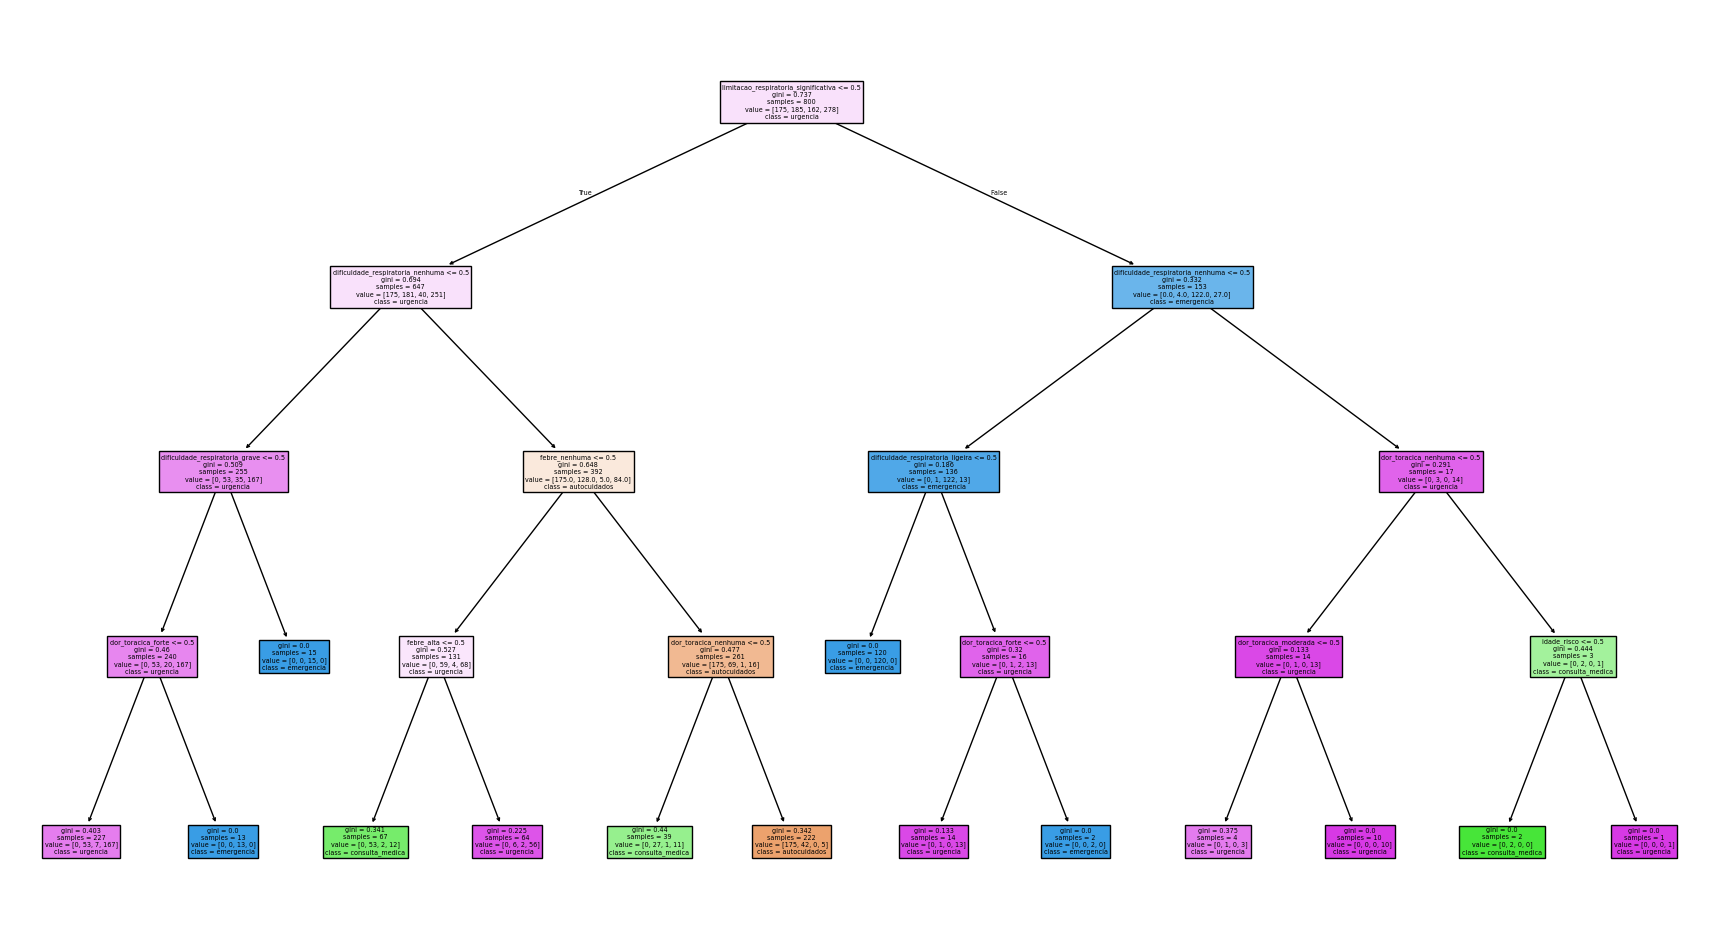

In [47]:
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree

plt.figure(figsize=(22, 12))
plot_tree(
    modelo,
    feature_names=X.columns,
    class_names=modelo.classes_,
    filled=True
)
plt.show()

In [48]:
from sklearn.tree import export_text

print(export_text(modelo, feature_names=list(X.columns)))

|--- limitacao_respiratoria_significativa <= 0.50
|   |--- dificuldade_respiratoria_nenhuma <= 0.50
|   |   |--- dificuldade_respiratoria_grave <= 0.50
|   |   |   |--- dor_toracica_forte <= 0.50
|   |   |   |   |--- class: urgencia
|   |   |   |--- dor_toracica_forte >  0.50
|   |   |   |   |--- class: emergencia
|   |   |--- dificuldade_respiratoria_grave >  0.50
|   |   |   |--- class: emergencia
|   |--- dificuldade_respiratoria_nenhuma >  0.50
|   |   |--- febre_nenhuma <= 0.50
|   |   |   |--- febre_alta <= 0.50
|   |   |   |   |--- class: consulta_medica
|   |   |   |--- febre_alta >  0.50
|   |   |   |   |--- class: urgencia
|   |   |--- febre_nenhuma >  0.50
|   |   |   |--- dor_toracica_nenhuma <= 0.50
|   |   |   |   |--- class: consulta_medica
|   |   |   |--- dor_toracica_nenhuma >  0.50
|   |   |   |   |--- class: autocuidados
|--- limitacao_respiratoria_significativa >  0.50
|   |--- dificuldade_respiratoria_nenhuma <= 0.50
|   |   |--- dificuldade_respiratoria_ligeira <

**ARVORE COM PROFUNDIDADE 3 E GINI**


In [49]:
from sklearn.tree import DecisionTreeClassifier

modelo_3 = DecisionTreeClassifier(max_depth=3, random_state=42)
modelo_3.fit(X_train, y_train)

DecisionTreeClassifier(max_depth=3, random_state=42)

In [50]:
y_pred_3 = modelo_3.predict(X_test)

In [51]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

print("Accuracy:", accuracy_score(y_test, y_pred_3))
print(classification_report(y_test, y_pred_3))
print(confusion_matrix(y_test, y_pred_3))

Accuracy: 0.685
                 precision    recall  f1-score   support

   autocuidados       0.63      1.00      0.77        44
consulta_medica       0.00      0.00      0.00        46
     emergencia       1.00      0.70      0.82        40
       urgencia       0.64      0.93      0.76        70

       accuracy                           0.69       200
      macro avg       0.57      0.66      0.59       200
   weighted avg       0.56      0.69      0.60       200

[[44  0  0  0]
 [21  0  0 25]
 [ 0  0 28 12]
 [ 5  0  0 65]]


c:\Users\pmtav\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\pmtav\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\pmtav\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


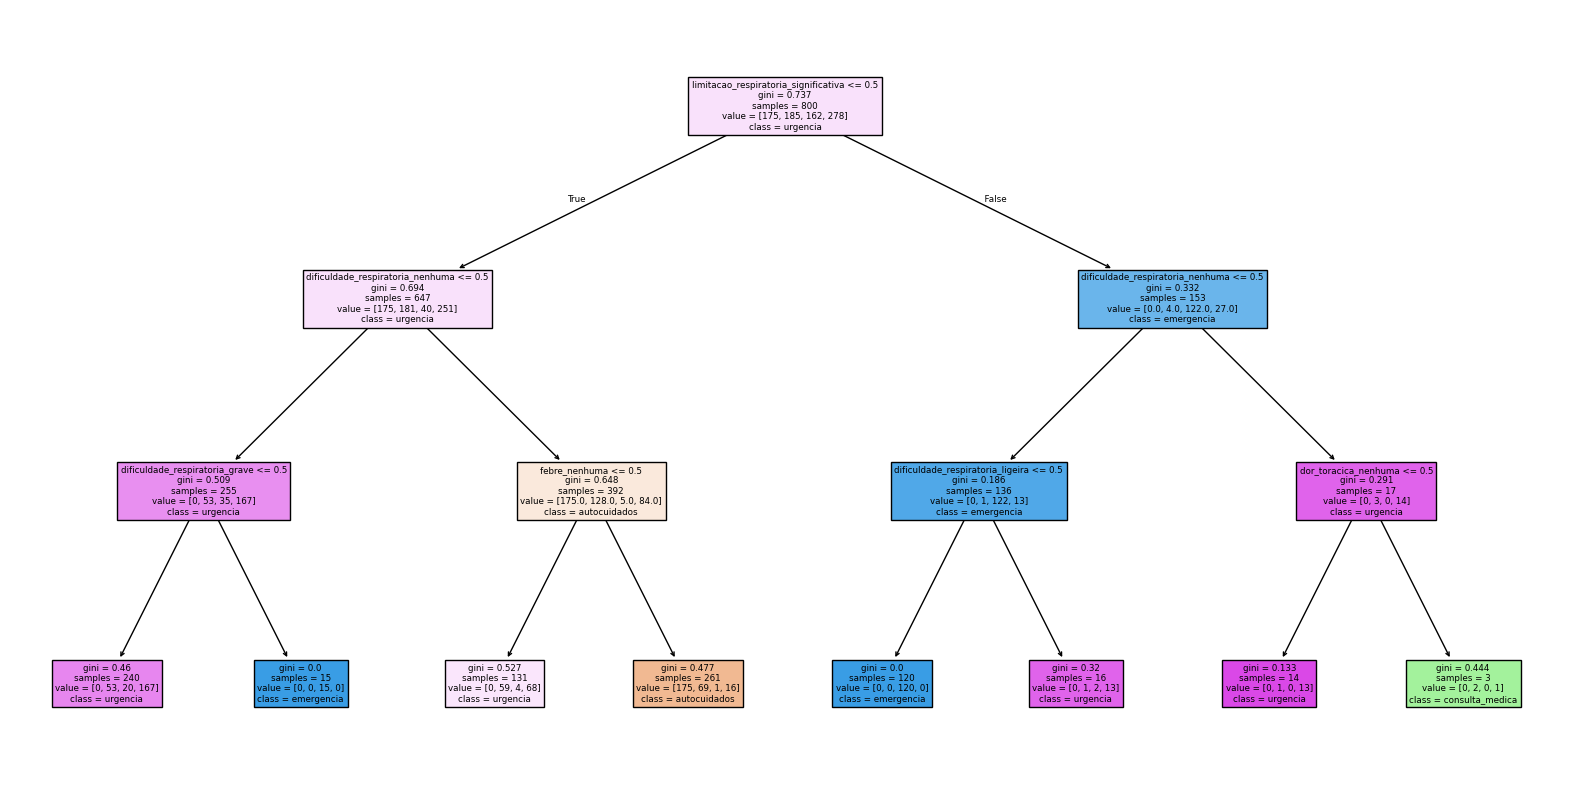

In [52]:
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree

plt.figure(figsize=(20, 10))
plot_tree(
    modelo_3,
    feature_names=X.columns,
    class_names=modelo_3.classes_,
    filled=True
)
plt.show()

In [53]:
from sklearn.tree import export_text

regras_3 = export_text(modelo_3, feature_names=list(X.columns))
print(regras_3)

|--- limitacao_respiratoria_significativa <= 0.50
|   |--- dificuldade_respiratoria_nenhuma <= 0.50
|   |   |--- dificuldade_respiratoria_grave <= 0.50
|   |   |   |--- class: urgencia
|   |   |--- dificuldade_respiratoria_grave >  0.50
|   |   |   |--- class: emergencia
|   |--- dificuldade_respiratoria_nenhuma >  0.50
|   |   |--- febre_nenhuma <= 0.50
|   |   |   |--- class: urgencia
|   |   |--- febre_nenhuma >  0.50
|   |   |   |--- class: autocuidados
|--- limitacao_respiratoria_significativa >  0.50
|   |--- dificuldade_respiratoria_nenhuma <= 0.50
|   |   |--- dificuldade_respiratoria_ligeira <= 0.50
|   |   |   |--- class: emergencia
|   |   |--- dificuldade_respiratoria_ligeira >  0.50
|   |   |   |--- class: urgencia
|   |--- dificuldade_respiratoria_nenhuma >  0.50
|   |   |--- dor_toracica_nenhuma <= 0.50
|   |   |   |--- class: urgencia
|   |   |--- dor_toracica_nenhuma >  0.50
|   |   |   |--- class: consulta_medica



In [54]:
import pandas as pd

importancias_3 = pd.Series(
    modelo_3.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

print(importancias_3)

limitacao_respiratoria_significativa    0.322684
dificuldade_respiratoria_nenhuma        0.309929
febre_nenhuma                           0.218397
dificuldade_respiratoria_ligeira        0.072776
dificuldade_respiratoria_grave          0.069902
dor_toracica_nenhuma                    0.006312
idade                                   0.000000
idade_risco                             0.000000
duracao_prolongada                      0.000000
agravamento                             0.000000
congestao_nasal                         0.000000
dor_garganta                            0.000000
pieira                                  0.000000
tosse                                   0.000000
febre_moderada                          0.000000
doenca_respiratoria_previa              0.000000
dificuldade_respiratoria_moderada       0.000000
febre_alta                              0.000000
imunossupressao                         0.000000
dor_toracica_ligeira                    0.000000
dor_toracica_moderad

**ARVORE C PROFUNDIADE 5 E GINI**   



In [55]:
from sklearn.tree import DecisionTreeClassifier

modelo_5 = DecisionTreeClassifier(max_depth=5, random_state=42)
modelo_5.fit(X_train, y_train)

DecisionTreeClassifier(max_depth=5, random_state=42)

In [56]:
y_pred_5 = modelo_5.predict(X_test)

In [57]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

print("Accuracy:", accuracy_score(y_test, y_pred_5))
print(classification_report(y_test, y_pred_5))
print(confusion_matrix(y_test, y_pred_5))

Accuracy: 0.86
                 precision    recall  f1-score   support

   autocuidados       0.88      1.00      0.94        44
consulta_medica       0.87      0.59      0.70        46
     emergencia       1.00      0.88      0.93        40
       urgencia       0.79      0.94      0.86        70

       accuracy                           0.86       200
      macro avg       0.88      0.85      0.86       200
   weighted avg       0.87      0.86      0.85       200

[[44  0  0  0]
 [ 6 27  0 13]
 [ 0  0 35  5]
 [ 0  4  0 66]]


In [60]:
print("Score treino:", modelo_5.score(X_train, y_train))
print("Score teste:", modelo_5.score(X_test, y_test))

Score treino: 0.86
Score teste: 0.86


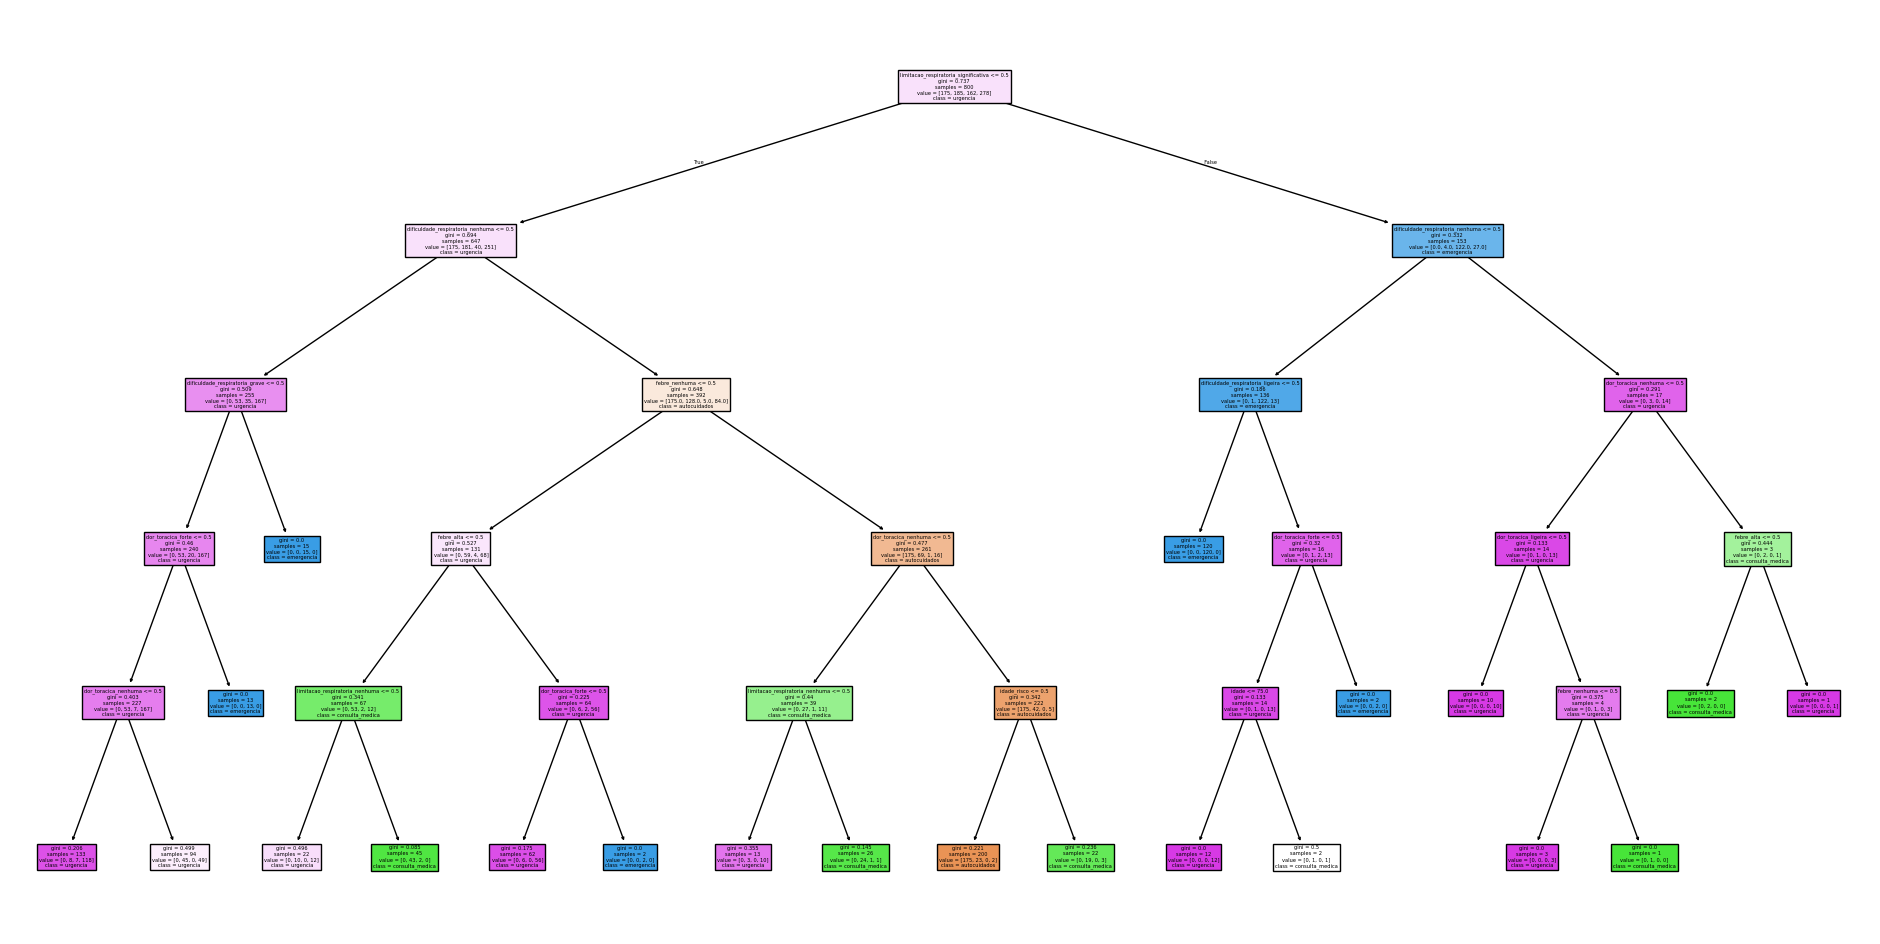

In [61]:
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree

plt.figure(figsize=(24, 12))
plot_tree(
    modelo_5,
    feature_names=X.columns,
    class_names=modelo_5.classes_,
    filled=True
)
plt.show()

In [62]:
from sklearn.tree import export_text

regras_5 = export_text(modelo_5, feature_names=list(X.columns))
print(regras_5)

|--- limitacao_respiratoria_significativa <= 0.50
|   |--- dificuldade_respiratoria_nenhuma <= 0.50
|   |   |--- dificuldade_respiratoria_grave <= 0.50
|   |   |   |--- dor_toracica_forte <= 0.50
|   |   |   |   |--- dor_toracica_nenhuma <= 0.50
|   |   |   |   |   |--- class: urgencia
|   |   |   |   |--- dor_toracica_nenhuma >  0.50
|   |   |   |   |   |--- class: urgencia
|   |   |   |--- dor_toracica_forte >  0.50
|   |   |   |   |--- class: emergencia
|   |   |--- dificuldade_respiratoria_grave >  0.50
|   |   |   |--- class: emergencia
|   |--- dificuldade_respiratoria_nenhuma >  0.50
|   |   |--- febre_nenhuma <= 0.50
|   |   |   |--- febre_alta <= 0.50
|   |   |   |   |--- limitacao_respiratoria_nenhuma <= 0.50
|   |   |   |   |   |--- class: urgencia
|   |   |   |   |--- limitacao_respiratoria_nenhuma >  0.50
|   |   |   |   |   |--- class: consulta_medica
|   |   |   |--- febre_alta >  0.50
|   |   |   |   |--- dor_toracica_forte <= 0.50
|   |   |   |   |   |--- class: urgenc

**ENTROPY C PROFUNDIDADE 4**


In [63]:
from sklearn.tree import DecisionTreeClassifier

modelo_entropy_4 = DecisionTreeClassifier(
    criterion="entropy",
    max_depth=4,
    random_state=42
)

modelo_entropy_4.fit(X_train, y_train)

DecisionTreeClassifier(criterion='entropy', max_depth=4, random_state=42)

In [64]:
y_pred_entropy_4 = modelo_entropy_4.predict(X_test)

In [65]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

print("Accuracy:", accuracy_score(y_test, y_pred_entropy_4))
print(classification_report(y_test, y_pred_entropy_4))
print(confusion_matrix(y_test, y_pred_entropy_4))

Accuracy: 0.81
                 precision    recall  f1-score   support

   autocuidados       0.77      1.00      0.87        44
consulta_medica       0.91      0.43      0.59        46
     emergencia       1.00      0.78      0.87        40
       urgencia       0.74      0.96      0.84        70

       accuracy                           0.81       200
      macro avg       0.86      0.79      0.79       200
   weighted avg       0.84      0.81      0.79       200

[[44  0  0  0]
 [12 20  0 14]
 [ 0  0 31  9]
 [ 1  2  0 67]]


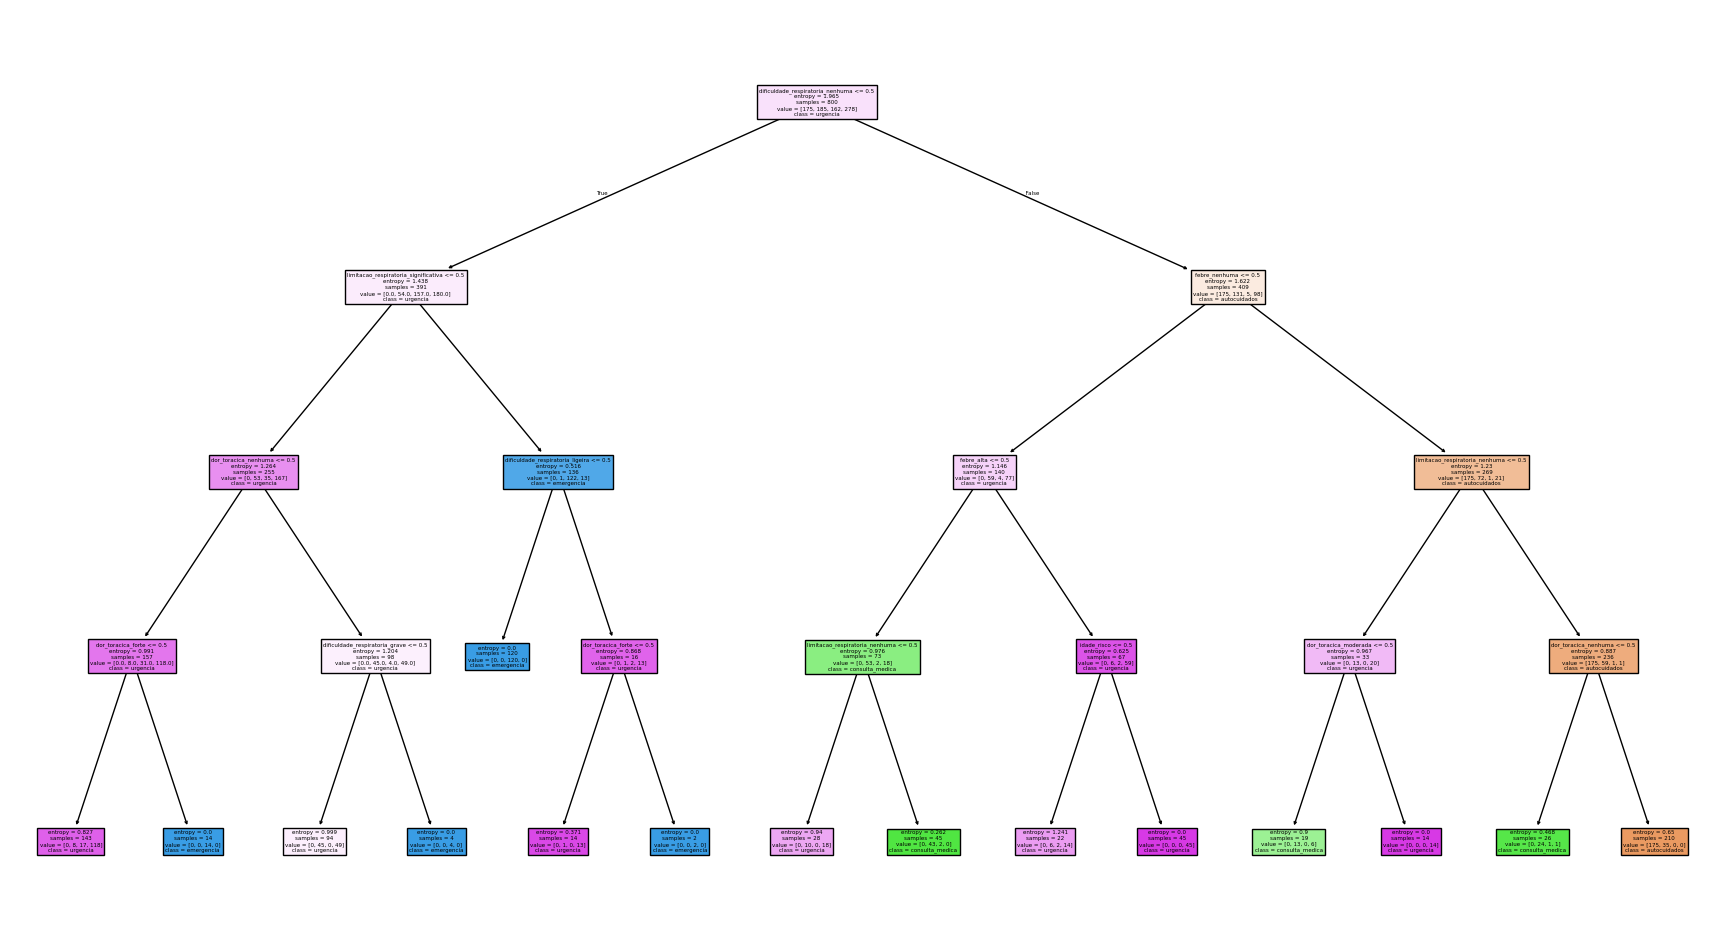

In [66]:
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree

plt.figure(figsize=(22, 12))
plot_tree(
    modelo_entropy_4,
    feature_names=X.columns,
    class_names=modelo_entropy_4.classes_,
    filled=True
)
plt.show()

In [67]:
from sklearn.tree import export_text

print(export_text(modelo_entropy_4, feature_names=list(X.columns)))

|--- dificuldade_respiratoria_nenhuma <= 0.50
|   |--- limitacao_respiratoria_significativa <= 0.50
|   |   |--- dor_toracica_nenhuma <= 0.50
|   |   |   |--- dor_toracica_forte <= 0.50
|   |   |   |   |--- class: urgencia
|   |   |   |--- dor_toracica_forte >  0.50
|   |   |   |   |--- class: emergencia
|   |   |--- dor_toracica_nenhuma >  0.50
|   |   |   |--- dificuldade_respiratoria_grave <= 0.50
|   |   |   |   |--- class: urgencia
|   |   |   |--- dificuldade_respiratoria_grave >  0.50
|   |   |   |   |--- class: emergencia
|   |--- limitacao_respiratoria_significativa >  0.50
|   |   |--- dificuldade_respiratoria_ligeira <= 0.50
|   |   |   |--- class: emergencia
|   |   |--- dificuldade_respiratoria_ligeira >  0.50
|   |   |   |--- dor_toracica_forte <= 0.50
|   |   |   |   |--- class: urgencia
|   |   |   |--- dor_toracica_forte >  0.50
|   |   |   |   |--- class: emergencia
|--- dificuldade_respiratoria_nenhuma >  0.50
|   |--- febre_nenhuma <= 0.50
|   |   |--- febre_alta <=

**ENTROPY COM PROFUNDIDADE 5**


In [68]:
modelo_entropy_5 = DecisionTreeClassifier(
    criterion="entropy",
    max_depth=5,
    random_state=42
)

modelo_entropy_5.fit(X_train, y_train)

DecisionTreeClassifier(criterion='entropy', max_depth=5, random_state=42)

In [69]:
y_pred_entropy_5 = modelo_entropy_5.predict(X_test)

In [70]:
print("Accuracy:", accuracy_score(y_test, y_pred_entropy_5))
print(classification_report(y_test, y_pred_entropy_5))
print(confusion_matrix(y_test, y_pred_entropy_5))

Accuracy: 0.865
                 precision    recall  f1-score   support

   autocuidados       0.90      1.00      0.95        44
consulta_medica       0.72      0.83      0.77        46
     emergencia       1.00      0.88      0.93        40
       urgencia       0.89      0.80      0.84        70

       accuracy                           0.86       200
      macro avg       0.88      0.88      0.87       200
   weighted avg       0.87      0.86      0.87       200

[[44  0  0  0]
 [ 5 38  0  3]
 [ 0  1 35  4]
 [ 0 14  0 56]]


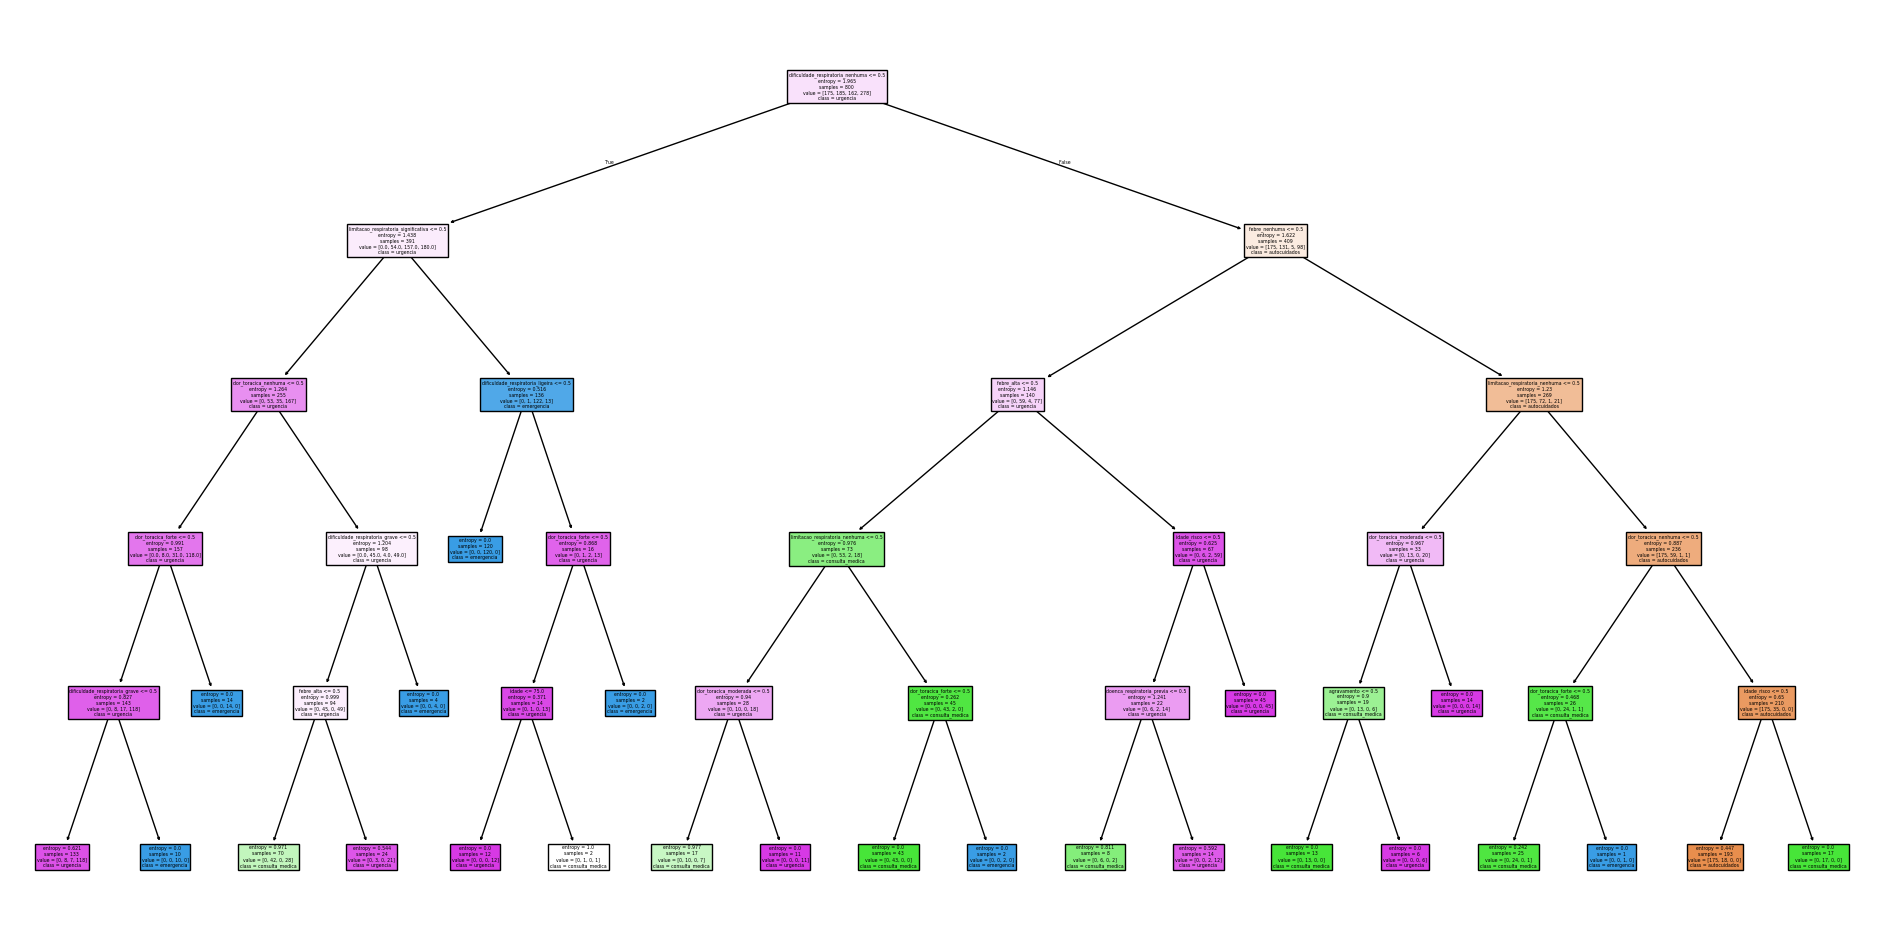

In [71]:
plt.figure(figsize=(24, 12))
plot_tree(
    modelo_entropy_5,
    feature_names=X.columns,
    class_names=modelo_entropy_5.classes_,
    filled=True
)
plt.show()

In [72]:
print(export_text(modelo_entropy_5, feature_names=list(X.columns)))

|--- dificuldade_respiratoria_nenhuma <= 0.50
|   |--- limitacao_respiratoria_significativa <= 0.50
|   |   |--- dor_toracica_nenhuma <= 0.50
|   |   |   |--- dor_toracica_forte <= 0.50
|   |   |   |   |--- dificuldade_respiratoria_grave <= 0.50
|   |   |   |   |   |--- class: urgencia
|   |   |   |   |--- dificuldade_respiratoria_grave >  0.50
|   |   |   |   |   |--- class: emergencia
|   |   |   |--- dor_toracica_forte >  0.50
|   |   |   |   |--- class: emergencia
|   |   |--- dor_toracica_nenhuma >  0.50
|   |   |   |--- dificuldade_respiratoria_grave <= 0.50
|   |   |   |   |--- febre_alta <= 0.50
|   |   |   |   |   |--- class: consulta_medica
|   |   |   |   |--- febre_alta >  0.50
|   |   |   |   |   |--- class: urgencia
|   |   |   |--- dificuldade_respiratoria_grave >  0.50
|   |   |   |   |--- class: emergencia
|   |--- limitacao_respiratoria_significativa >  0.50
|   |   |--- dificuldade_respiratoria_ligeira <= 0.50
|   |   |   |--- class: emergencia
|   |   |--- dificulda